# Tratamento da Unidade Móvel Centro

Este notebook organiza o tratamento horário da Unidade Móvel `Centro` em quatro blocos simples:

1. padronizar o calendário horário;
2. interpolar apenas lacunas internas curtas;
3. validar o impacto do tratamento.

## Bibliotecas e configurações

Começamos carregando as bibliotecas que serão usadas ao longo do notebook e localizando automaticamente a raiz do projeto. Isso evita depender do diretório manual de execução do notebook.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from decimal import Decimal, ROUND_HALF_EVEN

## Carregamento da base da Unidade Móvel

Nesta etapa, carregamos a base consolidada de qualidade do ar, normalizamos o nome da Unidade Móvel para evitar problemas de codificação e isolamos apenas os registros da Unidade Móvel `Centro`.

In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_um_centro = df_air_quality[df_air_quality["Nome"] == "UNIDADE MOVEL CENTRO"].copy()

df_um_centro["data"] = pd.to_datetime(df_um_centro["data"])
df_um_centro = df_um_centro.sort_values("data").reset_index(drop=True)
df_um_centro = df_um_centro.drop_duplicates(subset="data", keep="first")
df_um_centro = df_um_centro.set_index("data").sort_index().copy()

print("Dimensoes da base da Unidade Móvel Centro:", df_um_centro.shape)
display(df_um_centro.head())

Dimensoes da base da Unidade Móvel Centro: (2056, 14)


,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
data,,,,,,,,,,,,,,
2016-02-17 12:30:00,UNIDADE MOVEL CENTRO,0.0,28.66,71.01,0.92,NaN,NaN,NaN,NaN,5.29,NaN,NaN,-22.899568,-43.176431
2016-02-17 13:30:00,UNIDADE MOVEL CENTRO,0.0,30.76,56.50,0.00,NaN,0.03,NaN,NaN,5.02,NaN,NaN,-22.899568,-43.176431
2016-02-17 14:30:00,UNIDADE MOVEL CENTRO,0.0,31.25,59.36,1.16,NaN,0.19,NaN,NaN,11.36,NaN,NaN,-22.899568,-43.176431
2016-02-17 15:30:00,UNIDADE MOVEL CENTRO,0.0,29.91,66.83,0.58,NaN,0.04,NaN,NaN,13.86,NaN,NaN,-22.899568,-43.176431
2016-02-17 16:30:00,UNIDADE MOVEL CENTRO,0.0,29.08,67.06,0.00,NaN,0.05,NaN,NaN,11.51,NaN,0.0,-22.899568,-43.176431


## Resumo das faltas antes do tratamento

Com o calendário padronizado, agora medimos o tamanho do problema de missing antes de qualquer imputação. Essa tabela serve como linha de base para comparar o efeito do tratamento depois.

In [3]:
variaveis_ambientais = [
'no',
'no2',
'so2',
'pm2_5',
'nox',
'ur',
'temp',
'o3',
'co',
'pm10',
'chuva'
]
    

def resumir_faltantes(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    total_linhas = len(df)
    resumo = pd.DataFrame(index=variaveis)
    resumo["faltantes"] = [int(df[col].isna().sum()) for col in variaveis]
    resumo["missing_pct"] = [round(100 * df[col].isna().mean(), 2) for col in variaveis]
    resumo["validos"] = total_linhas - resumo["faltantes"]
    return resumo.sort_values("faltantes", ascending=False)


resumo_missing_antes = resumir_faltantes(df_um_centro, variaveis_ambientais)
display(resumo_missing_antes)

,faltantes,missing_pct,validos
no,2056,100.00,0
no2,2056,100.00,0
nox,2056,100.00,0
pm10,2056,100.00,0
co,517,25.15,1539
pm2_5,463,22.52,1593
so2,245,11.92,1811
o3,122,5.93,1934
ur,68,3.31,1988
temp,68,3.31,1988


## Regra de imputação adotada

O tratamento escolhido aqui é propositalmente conservador:

- interpolar apenas lacunas internas de até `4` horas consecutivas;
- não extrapolar bordas da série;
- não interpolar `chuva`, porque a interpolação linear pode criar eventos artificiais.

Com isso, preservamos a rastreabilidade do tratamento e evitamos preencher ausências longas ou estruturalmente mais problemáticas.

In [4]:
MAX_GAP_HORAS = 4

variaveis_interpolar = [
    "temp",
    "ur",
    "so2",
    "no2",
    "co",
    "no",
    "nox",
    "o3",
    "pm10",
    "pm2_5",
]


def mascara_lacunas_internas_curtas(serie: pd.Series, max_gap: int = 4) -> pd.Series:
    faltante = serie.isna()
    if not faltante.any():
        return pd.Series(False, index=serie.index)

    grupos = faltante.ne(faltante.shift(fill_value=False)).cumsum()
    tamanho_grupo = faltante.groupby(grupos).transform("sum")
    tem_valor_antes = serie.ffill().notna()
    tem_valor_depois = serie.bfill().notna()

    return faltante & tem_valor_antes & tem_valor_depois & (tamanho_grupo <= max_gap)

df_um_centro_tratado = df_um_centro.copy()

registros_imputacao = []

for variavel in variaveis_ambientais:
    serie_original = df_um_centro[variavel]

    if variavel in variaveis_interpolar:
        mascara_gap_curto = mascara_lacunas_internas_curtas(serie_original, max_gap=MAX_GAP_HORAS)
        serie_interpolada = serie_original.interpolate(method="time", limit_area="inside")
        df_um_centro_tratado.loc[mascara_gap_curto, variavel] = serie_interpolada.loc[mascara_gap_curto]
        valores_imputados = int((mascara_gap_curto & serie_interpolada.notna()).sum())
        metodo = "interpolate_time"

    else:
        mascara_gap_curto = pd.Series(False, index=serie_original.index)
        valores_imputados = 0
        metodo = "sem_interpolacao"

    registros_imputacao.append(
        {
            "variavel": variavel,
            "metodo": metodo,
            "faltantes_antes": int(serie_original.isna().sum()),
            "faltantes_depois": int(df_um_centro_tratado[variavel].isna().sum()),
            "valores_imputados": valores_imputados,
        }
    )

resumo_imputacao = pd.DataFrame(registros_imputacao).sort_values(
    ["valores_imputados", "faltantes_antes"],
    ascending=[False, False],
)

display(resumo_imputacao)

,variavel,metodo,faltantes_antes,faltantes_depois,valores_imputados
2,so2,interpolate_time,245,127,118
8,co,interpolate_time,517,412,105
3,pm2_5,interpolate_time,463,408,55
7,o3,interpolate_time,122,76,46
5,ur,interpolate_time,68,45,23
6,temp,interpolate_time,68,45,23
0,no,interpolate_time,2056,2056,0
1,no2,interpolate_time,2056,2056,0
4,nox,interpolate_time,2056,2056,0
9,pm10,interpolate_time,2056,2056,0


## Validação do impacto do tratamento

Depois da imputação, validamos o impacto em duas frentes:

- redução do missing por variável;
- estabilidade de estatísticas básicas antes e depois do tratamento.

Como a regra de imputação é curta e conservadora, a expectativa é reduzir uma parte das lacunas sem alterar de forma relevante o comportamento geral das séries.

Total de valores imputados: 370


,faltantes_antes,missing_pct_antes,faltantes_depois,missing_pct_depois,reducao_absoluta,reducao_relativa_pct
so2,245,11.92,127,6.18,118,48.16
co,517,25.15,412,20.04,105,20.31
pm2_5,463,22.52,408,19.84,55,11.88
o3,122,5.93,76,3.70,46,37.70
temp,68,3.31,45,2.19,23,33.82
ur,68,3.31,45,2.19,23,33.82
no,2056,100.00,2056,100.00,0,0.00
nox,2056,100.00,2056,100.00,0,0.00
no2,2056,100.00,2056,100.00,0,0.00
pm10,2056,100.00,2056,100.00,0,0.00


,media_antes,mediana_antes,desvio_padrao_antes,media_depois,mediana_depois,desvio_padrao_depois,delta_media,delta_desvio_padrao
so2,5.419729,3.45,6.917564,5.398926,3.390,6.992959,-0.020803,0.075395
pm2_5,16.114878,12.00,15.535014,15.978459,12.000,15.394983,-0.136419,-0.140032
ur,72.889276,75.08,11.604170,72.764345,74.920,11.635456,-0.124930,0.031287
temp,26.484145,26.52,3.138381,26.507646,26.520,3.144797,0.023501,0.006416
o3,21.719488,13.08,24.999720,22.088212,13.415,25.169351,0.368724,0.169631
co,0.152378,0.12,0.123453,0.152838,0.120,0.124219,0.000460,0.000766
chuva,0.118106,0.00,1.330131,0.118106,0.000,1.330131,0.000000,0.000000


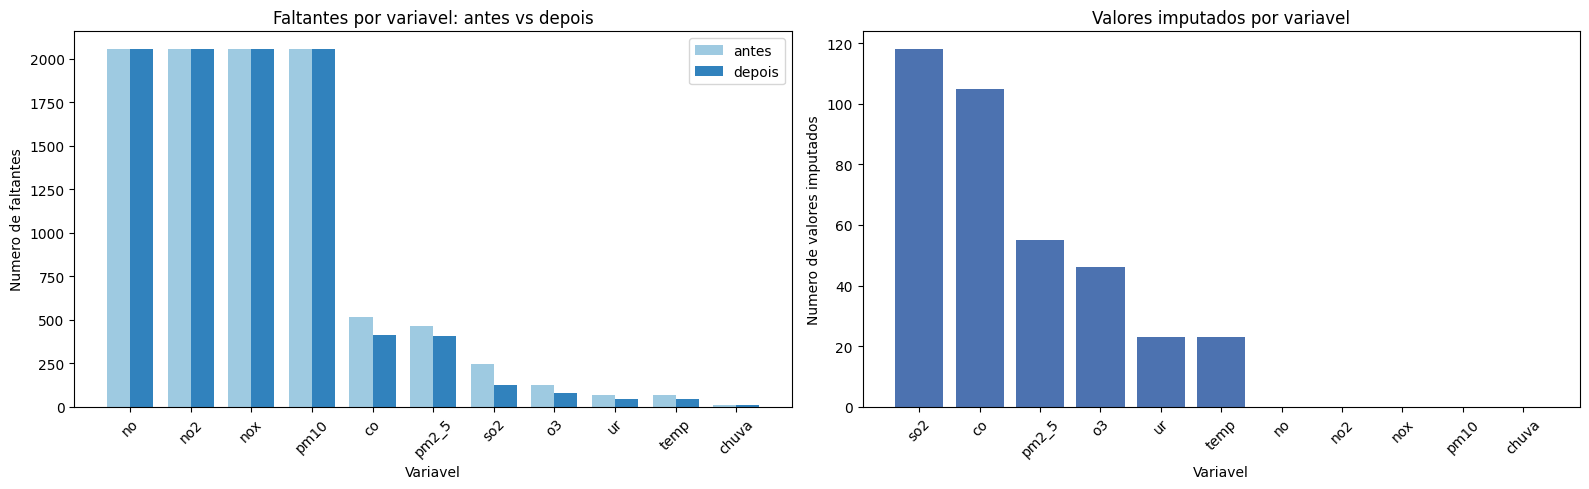

In [5]:
def estatisticas_basicas(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    resumo = pd.DataFrame(index=variaveis)
    resumo["media"] = [df[col].mean() for col in variaveis]
    resumo["mediana"] = [df[col].median() for col in variaveis]
    resumo["desvio_padrao"] = [df[col].std() for col in variaveis]
    return resumo


resumo_missing_depois = resumir_faltantes(df_um_centro_tratado, variaveis_ambientais)

comparativo_missing = resumo_missing_antes[["faltantes", "missing_pct"]].rename(
    columns={
        "faltantes": "faltantes_antes",
        "missing_pct": "missing_pct_antes",
    }
).join(
    resumo_missing_depois[["faltantes", "missing_pct"]].rename(
        columns={
            "faltantes": "faltantes_depois",
            "missing_pct": "missing_pct_depois",
        }
    )
)
comparativo_missing["reducao_absoluta"] = (
    comparativo_missing["faltantes_antes"] - comparativo_missing["faltantes_depois"]
)
comparativo_missing["reducao_relativa_pct"] = (
    100 * comparativo_missing["reducao_absoluta"] / comparativo_missing["faltantes_antes"].replace(0, pd.NA)
).round(2)

variaveis_com_dados = [
    variavel
    for variavel in variaveis_ambientais
    if df_um_centro[variavel].notna().any() or df_um_centro_tratado[variavel].notna().any()
]

estatisticas_antes = estatisticas_basicas(df_um_centro, variaveis_com_dados).add_suffix("_antes")
estatisticas_depois = estatisticas_basicas(df_um_centro_tratado, variaveis_com_dados).add_suffix("_depois")
comparativo_estatistico = estatisticas_antes.join(estatisticas_depois)
comparativo_estatistico["delta_media"] = (
    comparativo_estatistico["media_depois"] - comparativo_estatistico["media_antes"]
)
comparativo_estatistico["delta_desvio_padrao"] = (
    comparativo_estatistico["desvio_padrao_depois"] - comparativo_estatistico["desvio_padrao_antes"]
)

print(f"Total de valores imputados: {int(resumo_imputacao['valores_imputados'].sum())}")
display(comparativo_missing.sort_values("reducao_absoluta", ascending=False))
display(comparativo_estatistico)

comparativo_missing_plot = comparativo_missing.reset_index(names="variavel")
resumo_imputacao_plot = resumo_imputacao.sort_values("valores_imputados", ascending=False)

x_missing = range(len(comparativo_missing_plot))
largura = 0.38
x_imputacao = range(len(resumo_imputacao_plot))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    [x - largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_antes"],
    width=largura,
    label="antes",
    color="#9ecae1",
)
axes[0].bar(
    [x + largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_depois"],
    width=largura,
    label="depois",
    color="#3182bd",
)
axes[0].set_title("Faltantes por variavel: antes vs depois")
axes[0].set_xlabel("Variavel")
axes[0].set_ylabel("Numero de faltantes")
axes[0].set_xticks(list(x_missing))
axes[0].set_xticklabels(comparativo_missing_plot["variavel"], rotation=45)
axes[0].legend()

axes[1].bar(
    list(x_imputacao),
    resumo_imputacao_plot["valores_imputados"],
    color="#4c72b0",
)
axes[1].set_title("Valores imputados por variavel")
axes[1].set_xlabel("Variavel")
axes[1].set_ylabel("Numero de valores imputados")
axes[1].set_xticks(list(x_imputacao))
axes[1].set_xticklabels(resumo_imputacao_plot["variavel"], rotation=45)

plt.tight_layout()
plt.show()

## Calculo do Indice de Qualidade do Ar (AQI)

Nesta etapa, calculamos o AQI diario da estacao com base no documento tecnico de janeiro/2025 (IQAr), alinhado a Resolucao Conama no 506/2024.

### 1) Premissas regulatorias adotadas

Usamos a mesma logica descrita no documento:

- Calculamos um subindice por poluente (`pm10`, `pm2_5`, `o3`, `co`, `no2`, `so2`);
- O AQI diario e o maior subindice do dia;
- `o3` e `co`: maxima da media movel de 8 horas no dia;
- `no2`: maxima horaria no dia;
- `pm10`, `pm2_5` e `so2`: media de 24 horas;
- Arredondamento bancario (`ROUND_HALF_EVEN`):
  - `co` com 1 casa decimal;
  - demais poluentes sem casa decimal;
  - indice final arredondado para inteiro.

### 2) Tabela de faixas e implementacao

As faixas abaixo reproduzem o Quadro 1 do documento e sao aplicadas na interpolacao linear do indice em cada intervalo.


In [6]:
# Faixas de concentracao e indice (IQAr) conforme orientacao tecnica (jan/2025).
FAIXAS_IQAR = {
    'pm10_24h': [
        {'c_ini': 0, 'c_fin': 45, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 46, 'c_fin': 100, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 101, 'c_fin': 150, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 151, 'c_fin': 250, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 251, 'c_fin': 600, 'i_ini': 201, 'i_fin': 400},
    ],
    'pm2_5_24h': [
        {'c_ini': 0, 'c_fin': 15, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 16, 'c_fin': 50, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 51, 'c_fin': 75, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 76, 'c_fin': 125, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 126, 'c_fin': 300, 'i_ini': 201, 'i_fin': 400},
    ],
    'o3_8h_max': [
        {'c_ini': 0, 'c_fin': 100, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 101, 'c_fin': 130, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 131, 'c_fin': 160, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 161, 'c_fin': 200, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 201, 'c_fin': 800, 'i_ini': 201, 'i_fin': 400},
    ],
    'co_8h_max': [
        {'c_ini': 0.0, 'c_fin': 9.0, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 9.1, 'c_fin': 11.0, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 11.1, 'c_fin': 13.0, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 13.1, 'c_fin': 15.0, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 15.1, 'c_fin': 50.0, 'i_ini': 201, 'i_fin': 400},
    ],
    'no2_1h_max': [
        {'c_ini': 0, 'c_fin': 200, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 201, 'c_fin': 240, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 241, 'c_fin': 320, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 321, 'c_fin': 1130, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 1131, 'c_fin': 3750, 'i_ini': 201, 'i_fin': 400},
    ],
    'so2_24h': [
        {'c_ini': 0, 'c_fin': 40, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 41, 'c_fin': 50, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 51, 'c_fin': 125, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 126, 'c_fin': 800, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 801, 'c_fin': 2620, 'i_ini': 201, 'i_fin': 400},
    ],
}

def arredondar_bancario(valor: float, casas_decimais: int):
    """Aplica arredondamento ROUND_HALF_EVEN (arredondamento bancario)."""
    if pd.isna(valor):
        return pd.NA

    quantizador = Decimal('1') if casas_decimais == 0 else Decimal('0.1')
    valor_decimal = Decimal(str(valor)).quantize(quantizador, rounding=ROUND_HALF_EVEN)

    if casas_decimais == 0:
        return int(valor_decimal)
    return float(valor_decimal)

def calcular_subindice_iqar(concentracao: float, faixas: list[dict]):
    """Calcula o subindice de um poluente por interpolacao linear na faixa correspondente."""
    if pd.isna(concentracao):
        return pd.NA

    for faixa in faixas:
        if faixa['c_ini'] <= concentracao <= faixa['c_fin']:
            inclinacao = (faixa['i_fin'] - faixa['i_ini']) / (faixa['c_fin'] - faixa['c_ini'])
            indice = faixa['i_ini'] + inclinacao * (concentracao - faixa['c_ini'])
            return int(Decimal(str(indice)).quantize(Decimal('1'), rounding=ROUND_HALF_EVEN))

    # O Quadro 1 vai ate IQAr=400 (N5 - Pessima); acima do teto, saturamos no valor maximo.
    if concentracao > faixas[-1]['c_fin']:
        return 400

    return pd.NA

def classificar_iqar(indice: float):
    """Converte o indice numerico em faixa textual de qualidade do ar."""
    if pd.isna(indice):
        return pd.NA

    indice_int = int(indice)
    if indice_int <= 40:
        return 'N1 - Boa'
    if indice_int <= 80:
        return 'N2 - Moderada'
    if indice_int <= 120:
        return 'N3 - Ruim'
    if indice_int <= 200:
        return 'N4 - Muito Ruim'
    return 'N5 - Pessima'

def identificar_poluente_dominante(linha_subindices: pd.Series):
    """Retorna o poluente com maior subindice no dia."""
    validos = linha_subindices.dropna()
    if validos.empty:
        return pd.NA
    return validos.idxmax().replace('subindice_', '')

# Metricas diarias de entrada para o IQAr.
metricas_iqar_diarias = pd.DataFrame(index=df_um_centro_tratado.resample('D').size().index)
metricas_iqar_diarias['pm10_24h'] = df_um_centro_tratado['pm10'].resample('D').mean()
metricas_iqar_diarias['pm2_5_24h'] = df_um_centro_tratado['pm2_5'].resample('D').mean()
metricas_iqar_diarias['so2_24h'] = df_um_centro_tratado['so2'].resample('D').mean()
metricas_iqar_diarias['no2_1h_max'] = df_um_centro_tratado['no2'].resample('D').max()

# Para O3 e CO, usamos a maxima da media movel de 8h em cada dia.
metricas_iqar_diarias['o3_8h_max'] = (
    df_um_centro_tratado['o3']
    .rolling(window=8, min_periods=8)
    .mean()
    .resample('D')
    .max()
)
metricas_iqar_diarias['co_8h_max'] = (
    df_um_centro_tratado['co']
    .rolling(window=8, min_periods=8)
    .mean()
    .resample('D')
    .max()
)

# Padronizacao de arredondamento antes do calculo dos indices.
for coluna in ['pm10_24h', 'pm2_5_24h', 'o3_8h_max', 'no2_1h_max', 'so2_24h']:
    metricas_iqar_diarias[coluna] = metricas_iqar_diarias[coluna].apply(
        lambda valor: arredondar_bancario(valor, casas_decimais=0)
    )

metricas_iqar_diarias['co_8h_max'] = metricas_iqar_diarias['co_8h_max'].apply(
    lambda valor: arredondar_bancario(valor, casas_decimais=1)
)

# Calculo dos subindices por poluente.
mapeamento_subindices = {
    'pm10_24h': 'subindice_pm10',
    'pm2_5_24h': 'subindice_pm2_5',
    'o3_8h_max': 'subindice_o3',
    'co_8h_max': 'subindice_co',
    'no2_1h_max': 'subindice_no2',
    'so2_24h': 'subindice_so2',
}

subindices_iqar_diarios = pd.DataFrame(index=metricas_iqar_diarias.index)
for metrica, coluna_subindice in mapeamento_subindices.items():
    subindices_iqar_diarios[coluna_subindice] = metricas_iqar_diarias[metrica].apply(
        lambda concentracao: calcular_subindice_iqar(concentracao, FAIXAS_IQAR[metrica])
    )

# AQI diario = maior subindice entre os poluentes monitorados.
resumo_aqi_diario = pd.DataFrame(index=subindices_iqar_diarios.index)
resumo_aqi_diario['aqi'] = (
    subindices_iqar_diarios
    .apply(pd.to_numeric, errors='coerce')
    .max(axis=1, skipna=True)
    .astype('Int64')
)
resumo_aqi_diario['aqi_qualidade'] = resumo_aqi_diario['aqi'].apply(classificar_iqar)
resumo_aqi_diario['aqi_poluente_dominante'] = subindices_iqar_diarios.apply(
    identificar_poluente_dominante,
    axis=1,
)

display(resumo_aqi_diario.head())
display(subindices_iqar_diarios.head())


,aqi,aqi_qualidade,aqi_poluente_dominante
data,,,
2016-02-17,13,N1 - Boa,pm2_5
2016-02-18,24,N1 - Boa,pm2_5
2016-02-19,37,N1 - Boa,pm2_5
2016-02-20,42,N2 - Moderada,pm2_5
2016-02-21,<NA>,NaN,NaN


,subindice_pm10,subindice_pm2_5,subindice_o3,subindice_co,subindice_no2,subindice_so2
data,,,,,,
2016-02-17,<NA>,13,3,0,<NA>,0
2016-02-18,<NA>,24,20,1,<NA>,2
2016-02-19,<NA>,37,24,1,<NA>,8
2016-02-20,<NA>,42,18,1,<NA>,6
2016-02-21,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## Salvamento da base tratada

Por fim, salvamos a Unidade Movel `Centro`:

- Série diária agregada (média para as variáveis e soma diária para `chuva`).

Essa saída já ficam prontas para reutilização nas próximas etapas da pipeline.


In [7]:
project_root = Path().resolve().parents[4]
output_dir = project_root / "Data" / "IntermediaryData" / "MonitorAr" / "TreatedStations"
output_dir.mkdir(parents=True, exist_ok=True)

# Saída diária agregada:
# - média para a maior parte das variáveis
# - soma para chuva (preservando NaN quando o dia inteiro está faltante)

def somar_chuva_diaria(serie: pd.Series) -> float:
    return serie.sum(min_count=1)

agregacoes_diarias = {
    variavel: "mean"
    for variavel in variaveis_ambientais
    if variavel != "chuva"
}
agregacoes_diarias["chuva"] = somar_chuva_diaria

df_um_centro_diario = (
    df_um_centro_tratado[variaveis_ambientais]
    .resample("D")
    .agg(agregacoes_diarias)
)

# Incluimos o AQI diario e a classificacao de qualidade do ar calculados na secao anterior.
colunas_aqi_exportacao = resumo_aqi_diario[["aqi", "aqi_qualidade"]].rename(
    columns={"aqi_qualidade": "qualidade_do_ar"}
)
df_um_centro_diario = df_um_centro_diario.join(colunas_aqi_exportacao, how="left")

df_um_centro_diario_saida = df_um_centro_diario.reset_index()
output_csv_diario_path = output_dir / "um_centro_tratado_diario.csv"
df_um_centro_diario_saida.to_csv(output_csv_diario_path, index=False, encoding="utf-8")

print(f"Arquivo diario salvo em: {output_csv_diario_path}")
display(df_um_centro_diario_saida.head())


Arquivo diario salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\MonitorAr\TreatedStations\um_centro_tratado_diario.csv


,data,no,no2,so2,pm2_5,nox,ur,temp,o3,co,pm10,chuva,aqi,qualidade_do_ar
0,2016-02-17,NaN,NaN,0.221667,4.625000,NaN,73.903333,27.837500,6.025000,0.033636,NaN,0.0,13,N1 - Boa
1,2016-02-18,NaN,NaN,1.547083,8.791667,NaN,69.754167,28.336667,20.951875,0.099167,NaN,0.0,24,N1 - Boa
2,2016-02-19,NaN,NaN,8.190833,14.041667,NaN,71.122083,28.443750,27.695417,0.178333,NaN,30.0,37,N1 - Boa
3,2016-02-20,NaN,NaN,6.487941,16.611111,NaN,75.747647,28.147647,24.402941,0.218824,NaN,28.0,42,N2 - Moderada
4,2016-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,<NA>,NaN


## Resumo interpretativo do tratamento

O tratamento aplicado na `Unidade Móvel Centro` foi **conservador e com efeito moderado sobre a completude**, sem alterar de forma relevante o comportamento geral das séries. Ao todo, foram imputados `370` valores, com maior contribuição em `so2` (`118`), `co` (`105`), `pm2_5` (`55`) e `o3` (`46`). Em `temp` e `ur`, o ganho foi menor (`23` valores em cada), o que sugere que parte das lacunas restantes está em blocos mais longos do que a regra de até `4` horas consegue recuperar.

A principal melhora aconteceu nas variáveis efetivamente disponíveis da campanha. `so2` caiu de `11,92%` para `6,18%` de missing, `o3` de `5,93%` para `3,70%`, `temp` e `ur` de `3,31%` para `2,19%`, enquanto `co` e `pm2_5` também tiveram redução importante, embora ainda permaneçam mais sensíveis em completude. Em contrapartida, `no`, `no2`, `nox` e `pm10` seguiram com `100%` de missing, indicando ausências estruturais da base e não lacunas pontuais corrigíveis por interpolação.

A comparação estatística antes e depois mostra mudanças pequenas em `media`, `mediana` e `desvio padrao` nas variáveis com dados observados. Isso indica que a imputação curta recuperou parte das falhas internas sem distorcer de forma relevante a distribuição das séries. Em termos práticos, a base tratada da Unidade Móvel Centro fica um pouco mais robusta para as próximas etapas, mas sua capacidade analítica continua concentrada em `so2`, `co`, `pm2_5`, `o3`, `temp`, `ur` e `chuva`, dentro de uma campanha curta e com limitações estruturais em parte dos poluentes.